# Tutorial 3: Training DeepE2EROM Models

This tutorial demonstrates how to train end-to-end ROMs (as created in Tutorial 2) using processed sequences (Tutorial 1). We will use the `Trainer` module which handles the training loop, loss calculation, validation, and history tracking.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import deepe2erom
from deepe2erom import DataConfig, DataPreprocessor, create_model, Trainer

print(f"DeepE2EROM version: {deepe2erom.__version__}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DeepE2EROM version: 0.1.0
Using device: cuda


### Data Preparation

First, we generate synthetic data from the **1D heat equation with control input**.
The state is a high-dimensional 1D field $u(x,t)$, and the control is a scalar source amplitude distributed smoothly across the domain.


In [2]:
# --- Generate Synthetic Data: Diffusing Gaussian with Controlled Source ---
# PDE: u_t = alpha*u_xx + b(x)*a(t)
# Domain: periodic, x in [0, 2*pi)

n_simulations = 5000
n_timesteps = 100
state_dim = 64
control_dim = 1

states = np.zeros((n_simulations, n_timesteps, state_dim), dtype=np.float32)
controls = np.zeros((n_simulations, n_timesteps, control_dim), dtype=np.float32)

# Numerical / physical parameters
alpha = 0.08    # diffusion coefficient
dt = 0.02       # time step
L = 2.0 * np.pi
dx = L / state_dim
x_grid = np.linspace(0.0, L, state_dim, endpoint=False)

# Smooth source-shape function b(x) over the full domain
forcing_profile = np.sin(x_grid) + 0.5 * np.cos(2.0 * x_grid - 0.4)

def periodic_dxx(u, dx):
    return (np.roll(u, -1) - 2.0 * u + np.roll(u, 1)) / (dx ** 2)

for sim in range(n_simulations):
    # Smooth scalar control signal a(t): bounded random walk
    a = np.zeros(n_timesteps, dtype=np.float32)
    a_val = np.random.uniform(-0.3, 0.3)
    for t in range(n_timesteps):
        a_val += np.random.normal(0.0, 0.06)
        a_val = np.clip(a_val, -1.0, 1.0)
        a[t] = a_val

    controls[sim, :, 0] = a

    # Gaussian initial condition
    x0 = np.random.uniform(0.2 * L, 0.8 * L)
    sigma = np.random.uniform(0.25, 0.55)
    amp = np.random.uniform(0.8, 1.2)
    u = (amp * np.exp(-((x_grid - x0) ** 2) / (2.0 * sigma ** 2))).astype(np.float32)

    for t in range(n_timesteps):
        states[sim, t] = u

        uxx = periodic_dxx(u, dx)

        # Explicit Euler update: diffusion + controlled source
        rhs = alpha * uxx + a[t] * forcing_profile
        u = u + dt * rhs

print(f"Generated data: States {states.shape}, Controls {controls.shape}")
print(f"Data Range: [{states.min():.3f}, {states.max():.3f}]")

Generated data: States (5000, 100, 64), Controls (5000, 100, 1)
Data Range: [-2.140, 2.723]


In [3]:
# visualize one simulation
from deepe2erom import animate_1Dsimulation
animate_1Dsimulation(states[4], save_path="./03_Training_outputs/simulation_sample.gif", title="Gaussian Diffusion with Controlled Source")

Preprocess the simulation data for training using the `DataPreprocessor`:

In [4]:
# --- Process Data ---
lookback = 10
pred_horizon = 10
state_dim = states.shape[2]
control_dim = controls.shape[2]
config = DataConfig(
    # Data splitting
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,

    # state and control dimensions
    state_dim=state_dim,
    control_dim=control_dim,
    
    # Sequence parameters
    lookback=lookback,              # Use lookback past time steps as input
    pred_horizon=pred_horizon,      # Predict pred_horizon future time steps
    stride=1,                       # No skipping between sequences
    
    # Scaling
    scale_states=False,
    scale_controls=True,
    scale_states_collectively=False,     # Scale all states together (one high-dimensional field)
    scale_controls_collectively=False,   # Not relevant for low-dimensional controls
    scaling_method="minmax",             # Scaling method: "minmax" or "standard"
    
    # Device
    device=device
)

processor = DataPreprocessor(config)
processed_data = processor.process_simulations(states, controls)

Scaling controls using:  minmax


After preprocessing, the processed sequences can be efficiently loaded into a PyTorch `DataLoader` for batch processing. The `DataLoader` handles:

- **Batching**: Groups individual sequences into batches for parallel processing
- **Shuffling**: Randomizes sample order (typically for training data)
- **Parallel Loading**: Utilizes multiple workers for faster data loading

In [5]:
# Create DataLoaders
batch_size = 128
train_loader = DataLoader(processed_data['datasets']['train'], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(processed_data['datasets']['val'], batch_size=batch_size)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 2532
Val batches: 317


### Model Creation

We create a ROM with LSTM latent dynamics for this data.

In [6]:
latent_dim = 4

# Encoder/Decoder Architectures
encoder_arch = [
    {"type": "Linear", "params": {"in_features": state_dim, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": latent_dim}},
    {"type": "Sigmoid"},
]

decoder_arch = [
    {"type": "Linear", "params": {"in_features": latent_dim, "out_features": 32}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 32, "out_features": 64}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 64, "out_features": state_dim}},
]

model = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=config.lookback,
    pred_horizon=config.pred_horizon,
    latent_dim=latent_dim,
    dynamics_type="linear",
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    device=device,
    seed=42
)

print("Model created successfully.")

model.count_parameters()

Model created successfully.
MODEL PARAMETER COUNT
encoder         |    6,372 total |    6,372 trainable
decoder         |    6,432 total |    6,432 trainable
dynamics        |      208 total |      208 trainable
------------------------------------------------------------
TOTAL           |   13,012 total |   13,012 trainable


{'encoder': {'total': 6372, 'trainable': 6372},
 'decoder': {'total': 6432, 'trainable': 6432},
 'dynamics': {'total': 208, 'trainable': 208},
 'total': {'total': 13012, 'trainable': 13012}}

### The Trainer Module

The `Trainer` class simplifies the training process. It manages the optimization of a composite loss function consisting of:

1.  **Reconstruction Loss** (`rec_loss`): MSE between original and reconstructed states.
2.  **Prediction Loss** (`pred_loss`): MSE between predicted future states and ground truth.
3.  **Latent Consistency Loss** (`latent_loss`): MSE between predicted latent states and encoded ground truth states.
4.  **Input Reconstruction Loss** (`input_rec_loss`): (Optional) If using a control autoencoder.

You can weight these components to guide training.

In addition, the `Trainer` class defines the number of training restarts `(restarts_ae, restarts_e2e)` to find the best initialization.

In [7]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    rec_weight=1.0,         # Weight for state reconstruction
    input_rec_weight=0.0,   # Weight for control reconstruction
    pred_weight=0.3,        # Weight for future prediction
    latent_weight=1.0,      # Weight for latent space consistency
    learning_rate=1e-3,     # Learning rate
    restarts_ae=2,          # Number of autoencoder restarts (pre-training phase)
    restarts_e2e=2,         # Number of training restarts (full training phase)
    device=device,
)

print("Trainer initialized.")

Trainer initialized.


### Training Loop

The `train` method executes the training pipeline, which consists of two stages:

1.  **Autoencoder Pre-training**: Trains only the autoencoders for `ae_epochs` to establish a good latent space before learning dynamics.
2.  **Full Training**: Trains the entire end-to-end model for `epochs`.

The training loop has the following features:
 - **Restarts**: Can run the training multiple times (`restarts_ae` for pre-training phase and `restarts_e2e` for full training) to find the best initialization.
 - **Early Stopping**: Monitors validation loss to stop if no improvement is seen for `patience_early_stopping` epochs.
 - **Learning Rate Schedulizer**: The learning rate is reduced by half if the validation loss did not improve for `patience_lr_scheduler` epochs.
 - **Saving**: Saves the best model and training history to `save_path`.

In [8]:
save_dir = "./03_Training_outputs"

best_loss = trainer.train(
    train_loader=train_loader,
    valid_data=val_loader,
    epochs=100,                          # Maximum epochs for full training
    ae_epochs=10,                        # Pre-train autoencoders for 10 epochs                     
    patience_early_stopping=20,          # Early stopping patience
    patience_lr_scheduler=10,            # LR scheduler patience
    save_path=save_dir,
    seed=42
)

print(f"Training finished. Best validation loss: {best_loss:.6f}")

  AE Restart 1/2
    Training States Autoencoder for 10 epochs...
Epoch 1 - New best state AE validation loss: 0.000979
Epoch 2 - New best state AE validation loss: 0.000704
Epoch 3 - New best state AE validation loss: 0.000617
Epoch 4 - New best state AE validation loss: 0.000548
Epoch 5 - New best state AE validation loss: 0.000533
Epoch 6 - New best state AE validation loss: 0.000429
Epoch 7 - New best state AE validation loss: 0.000385
Epoch 8 - New best state AE validation loss: 0.000379
Epoch 9 - New best state AE validation loss: 0.000357
Epoch 10 - New best state AE validation loss: 0.000318
  AE Restart 2/2
    Training States Autoencoder for 10 epochs...

Starting run 1/2
Starting full training for 100 epochs...
Epoch 1/100 - Train Loss: 0.010494 - Val Loss: 0.001102
New best model found with validation loss: 0.001102
Epoch 2/100 - Train Loss: 0.000794 - Val Loss: 0.000634
New best model found with validation loss: 0.000634
Epoch 3/100 - Train Loss: 0.000526 - Val Loss: 0.000

### Evaluation & Visualization

The trainer saves the training history and plots to the specified directory. We can visualize the learning curves to check for convergence and overfitting.

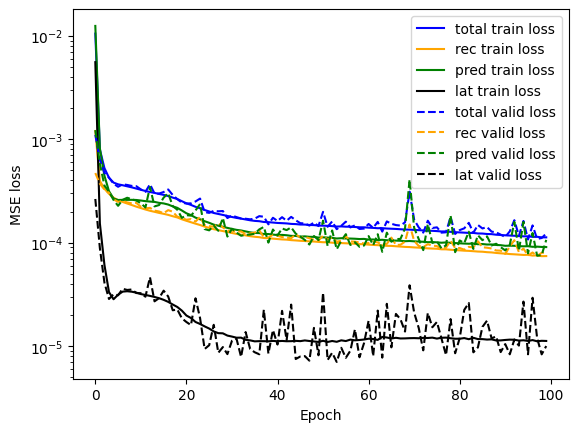

In [9]:
import pickle
import os

# Load history
save_dir = "./03_Training_outputs"
history_path = os.path.join(save_dir, "history.pkl")
with open(history_path, "rb") as f:
    history = pickle.load(f)

# Plot Learning Curves
fig, axs = plt.subplots()
axs.set_yscale('log')
axs.set_xlabel('Epoch')
axs.set_ylabel('MSE loss')
axs.plot(history['avg_epoch_total_loss_train'], color='blue', linestyle='-', label='total train loss')
axs.plot(history['avg_epoch_rec_loss_train'], color='orange', linestyle='-', label='rec train loss')
axs.plot(history['avg_epoch_pred_loss_train'], color='green', linestyle='-', label='pred train loss')
axs.plot(history['avg_epoch_lat_loss_train'], color='black', linestyle='-', label='lat train loss')

axs.plot(history['epoch_total_loss_valid'], color='blue', linestyle='--', label='total valid loss')
axs.plot(history['epoch_rec_loss_valid'], color='orange', linestyle='--', label='rec valid loss')
axs.plot(history['epoch_pred_loss_valid'], color='green', linestyle='--', label='pred valid loss')
axs.plot(history['epoch_lat_loss_valid'], color='black', linestyle='--', label='lat valid loss')
axs.legend()

### Model Inference

The trained model is used to predict a new trajectory. For this, the `simulate` method is used. We provide the initial condition (lookback window) and the control sequence to the model. The model autoregressively predicts the future states in the latent space and decodes them back to the physical space. We compare the predicted latent dynamics against the "true" latents (obtained by encoding the ground truth states) and the predicted physical states against the ground truth.

In [17]:
# load the model
model.load_state_dict(torch.load('./03_Training_outputs/best_model.pth'))
model.eval()

# Evaluate a test simulation
sim_idx = 42
sim_length = 50
init_idx = 0
test_sim = processed_data['simulations']['test'][sim_idx]

# Use SCALED signals for inference
X0 = test_sim.states_scaled[0, init_idx:init_idx + lookback]
U = test_sim.controls_scaled[0, init_idx:]

# Ground truth states in the same scaled space
true_states = test_sim.states_scaled[0, init_idx + lookback:init_idx + lookback + sim_length]

# Simulate (inputs should not be batched)
with torch.no_grad():
    pred_latents, pred_states = model.simulate(X0, U, sim_length)

# Get the true latents
model.eval()
with torch.no_grad():
    true_latents = model.encoder(true_states).cpu()

# move to cpu for plotting/animation
true_states = true_states.cpu()
pred_states = pred_states.cpu()
pred_latents = pred_latents.cpu()

print('X0 shape:', X0.shape)
print('U shape:', U.shape)
print('true_states shape:', true_states.shape)
print('pred_states shape:', pred_states.shape)

X0 shape: torch.Size([10, 64])
U shape: torch.Size([100, 1])
true_states shape: torch.Size([50, 64])
pred_states shape: torch.Size([50, 64])


We visualize first the preduicted dynamics within the latent space:

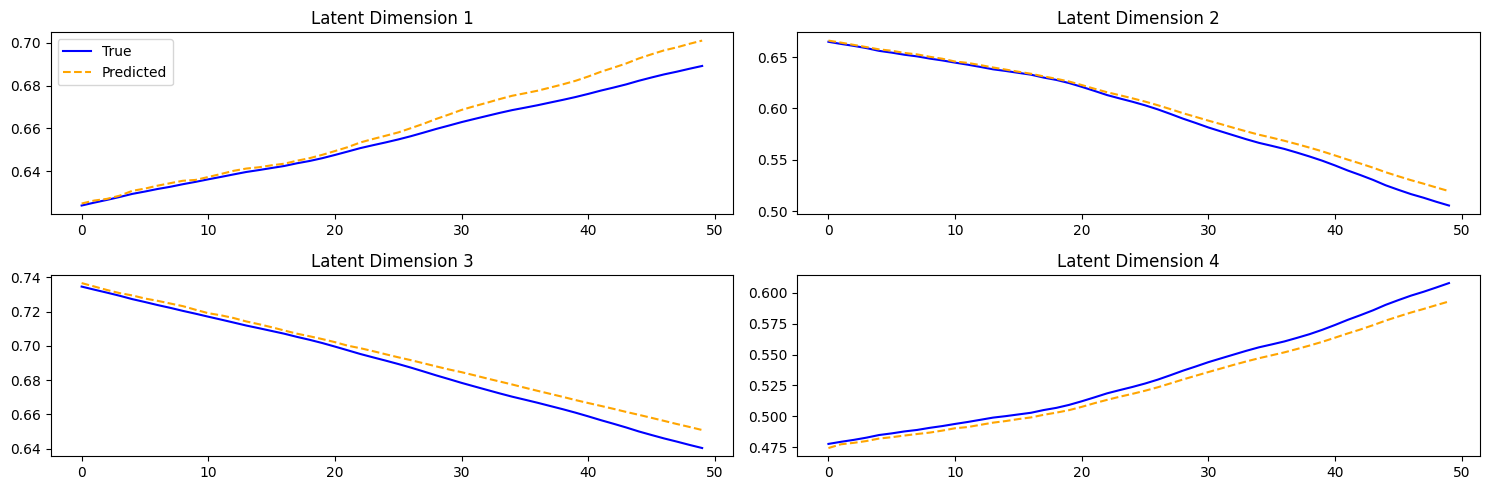

In [18]:
plt.figure(figsize=(15, 5))
for i in range(latent_dim):
    plt.subplot(2, latent_dim//2, i+1)
    plt.plot(true_latents[:, i], label='True', color='blue')
    plt.plot(pred_latents[:, i], label='Predicted', color='orange', linestyle='--')
    plt.title(f'Latent Dimension {i+1}')
    #plt.ylim([0,1])
    if i == 0:
        plt.legend()
plt.tight_layout()
plt.show()

Second, we visualize the decoded high-dimensional states:

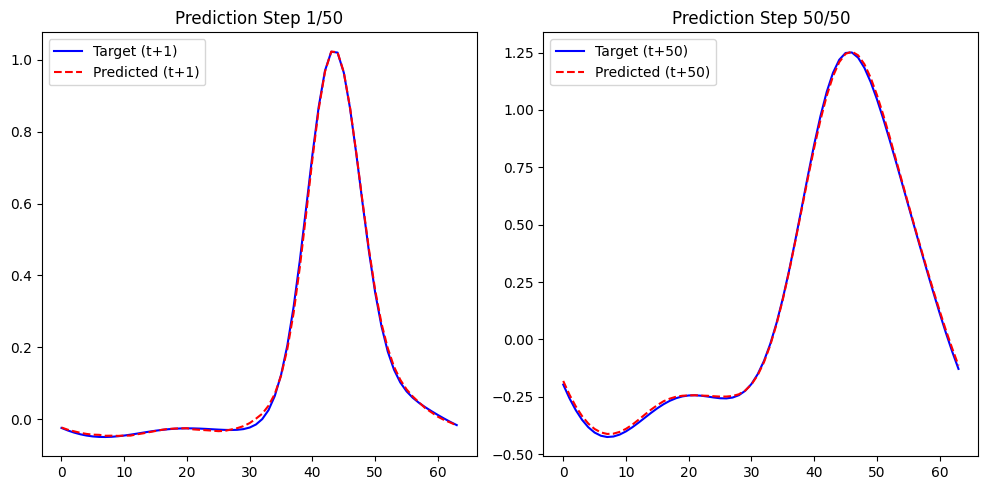

Comparison animation saved to: ./03_Training_outputs/1D_simulation_prediction.gif


In [19]:
# Plotting
plt.figure(figsize=(15, 5))

# 2. Future Prediction (First Step)
plt.subplot(1, 3, 1)
plt.plot(true_states[0].cpu(), 'b-', label='Target (t+1)')
plt.plot(pred_states[0], 'r--', label='Predicted (t+1)')
plt.title(f"Prediction Step 1/{sim_length}")
plt.legend()

# 3. Future Prediction (Last Step)
plt.subplot(1, 3, 2)
plt.plot(true_states[-1].cpu(), 'b-', label=f'Target (t+{sim_length})')
plt.plot(pred_states[-1], 'r--', label=f'Predicted (t+{sim_length})')
plt.title(f"Prediction Step {sim_length}/{sim_length}")
plt.legend()

plt.tight_layout()
plt.show()

# save the animation
from deepe2erom import animate_compare_1Dsimulations
animate_compare_1Dsimulations(true_states, pred_states, labels=["Ground truth", "Prediction"], save_path="./03_Training_outputs/1D_simulation_prediction.gif")